In [4]:
import os
import shutil
import pandas as pd

In [5]:
EXPORT_FOLDER = 'unet_singan_augmented_datasets_2'
os.makedirs(EXPORT_FOLDER, exist_ok=True)

In [6]:
HQ_SAMPLES_FOLDER = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/unet_singan_augmented_datasets/augmented_dataset_expansion_factor_16.0_hq_samples'

In [7]:
import numpy as np

In [43]:
# Clear export folder
shutil.rmtree(EXPORT_FOLDER, ignore_errors=True)

In [28]:
len(sampled_synthetic_images_df['base_image'].unique())

115

In [29]:
target_qt // len(sampled_synthetic_images_df['base_image'].unique())

2

In [37]:
sampled_synthetic_images['base_image'].value_counts()

base_image
FD-031-slice-24    6
FD-027-slice-02    5
FD-027-slice-01    5
FD-027-slice-04    5
FD-027-slice-06    5
                  ..
FD-032-slice-67    5
FD-032-slice-68    5
FD-032-slice-69    5
FD-032-slice-70    5
FD-032-slice-72    5
Name: count, Length: 115, dtype: int64

In [44]:
for expansion_factor in [
    0.5, 1.0, 2.0, 4.0, 8.0, 16.0
]:
    for folder in os.listdir(HQ_SAMPLES_FOLDER):
        train_path = os.path.join(HQ_SAMPLES_FOLDER, folder, 'train')
        val_path = os.path.join(HQ_SAMPLES_FOLDER, folder, 'val')

        real_train_images = [img for img in os.listdir(train_path) if 'synthetic' not in img and 'mask' not in img]
        synthetic_train_images = [img for img in os.listdir(train_path) if 'synthetic' in img and 'mask' not in img]

        target_qt = int(len(real_train_images) * expansion_factor)

        sampled_synthetic_images_df = pd.DataFrame({
            'image': synthetic_train_images,
            'base_image': [img[:img.find('-image-synthetic')] for img in synthetic_train_images]
        })

        num_unique_base_images = len(sampled_synthetic_images_df['base_image'].unique())
        target_qt_per_base_image = max(target_qt // num_unique_base_images, 1)

        # Randomly sample the synthetic iamges

        # compute how many bases and the even split
        bases = sampled_synthetic_images_df['base_image'].unique()
        n_bases = len(bases)

        per_base = target_qt // n_bases
        remainder = target_qt % n_bases

        # randomly choose which bases get one extra sample
        extra_bases = set(np.random.choice(bases, size=remainder, replace=False))

        # for each base, sample per_base (+1 if in extra_bases)
        samples = []
        for base, group in sampled_synthetic_images_df.groupby('base_image'):
            n = per_base + (1 if base in extra_bases else 0)
            # if you might request more than exist, set replace=True or clamp n
            replace = n > len(group)
            samples.append(group.sample(n=n, replace=replace))

        sampled_synthetic_images = pd.concat(samples).reset_index(drop=True)
        # sanity check
        assert len(sampled_synthetic_images) == target_qt

        sampled_synthetic_images = sampled_synthetic_images['image'].tolist()

        # Copy the sampled synthetic images to the export folder
        new_export_folder = os.path.join(EXPORT_FOLDER, f'augmented_dataset_expansion_factor_{expansion_factor}', folder)

        os.makedirs(new_export_folder, exist_ok=True)
        os.makedirs(os.path.join(new_export_folder, 'train'), exist_ok=True)
        os.makedirs(os.path.join(new_export_folder, 'val'), exist_ok=True)

        # Copy real images (all of them)
        for img in real_train_images:
            shutil.copy(os.path.join(train_path, img), os.path.join(new_export_folder, 'train', img))

            # Copy the mask image
            mask_img = img.replace('image.png', 'mask.png')
            shutil.copy(os.path.join(train_path, mask_img), os.path.join(new_export_folder, 'train', mask_img))

        # Copy sampled synthetic images
        for img in sampled_synthetic_images:
            shutil.copy(os.path.join(train_path, img), os.path.join(new_export_folder, 'train', img))

            # Copy the mask image
            mask_img = img.replace('_img.png', '_mask.png')
            shutil.copy(os.path.join(train_path, mask_img), os.path.join(new_export_folder, 'train', mask_img))

        # Copy all validation images
        for img in os.listdir(val_path):
            shutil.copy(os.path.join(val_path, img), os.path.join(new_export_folder, 'val', img))
        print(f'Created dataset with expansion factor {expansion_factor} in {new_export_folder}')

Created dataset with expansion factor 0.5 in unet_singan_augmented_datasets_2/augmented_dataset_expansion_factor_0.5/FD-030
Created dataset with expansion factor 0.5 in unet_singan_augmented_datasets_2/augmented_dataset_expansion_factor_0.5/FD-027
Created dataset with expansion factor 0.5 in unet_singan_augmented_datasets_2/augmented_dataset_expansion_factor_0.5/FD-029
Created dataset with expansion factor 0.5 in unet_singan_augmented_datasets_2/augmented_dataset_expansion_factor_0.5/FD-032
Created dataset with expansion factor 0.5 in unet_singan_augmented_datasets_2/augmented_dataset_expansion_factor_0.5/FD-031
Created dataset with expansion factor 1.0 in unet_singan_augmented_datasets_2/augmented_dataset_expansion_factor_1.0/FD-030
Created dataset with expansion factor 1.0 in unet_singan_augmented_datasets_2/augmented_dataset_expansion_factor_1.0/FD-027
Created dataset with expansion factor 1.0 in unet_singan_augmented_datasets_2/augmented_dataset_expansion_factor_1.0/FD-029
Created 

In [10]:
SINGAN_AUGMENTED_DATASETS_PATH = EXPORT_FOLDER

In [55]:
dataset_sizes = []
for folder in os.listdir(SINGAN_AUGMENTED_DATASETS_PATH):
    for cv_subject in os.listdir(os.path.join(SINGAN_AUGMENTED_DATASETS_PATH, folder)):
        train_folder_path = os.path.join(SINGAN_AUGMENTED_DATASETS_PATH, folder, cv_subject, 'train')
        val_folder_path = os.path.join(SINGAN_AUGMENTED_DATASETS_PATH, folder, cv_subject, 'val')

        num_train_folder_non_mask_samples = len([f for f in os.listdir(train_folder_path) if 'mask' not in f])
        train_samples_synthetic = len([f for f in os.listdir(train_folder_path) if 'synthetic' in f and 'mask' not in f])
        num_val_folder_non_mask_samples = len([f for f in os.listdir(val_folder_path) if 'mask' not in f])
        dataset_sizes.append({
            'folder': folder,
            'cv_subject': cv_subject,
            'train_samples': num_train_folder_non_mask_samples,
            'train_samples_synthetic': train_samples_synthetic,
            'train_samples_real': num_train_folder_non_mask_samples - train_samples_synthetic,
            'val_samples': num_val_folder_non_mask_samples
        })

In [57]:
pd.DataFrame(dataset_sizes)

,folder,cv_subject,train_samples,train_samples_synthetic,train_samples_real,val_samples
0,augmented_dataset_expansion_factor_2.0,FD-030,861,573,288,72
1,augmented_dataset_expansion_factor_2.0,FD-027,860,572,288,72
2,augmented_dataset_expansion_factor_2.0,FD-029,859,571,288,72
3,augmented_dataset_expansion_factor_2.0,FD-032,861,573,288,72
4,augmented_dataset_expansion_factor_2.0,FD-031,864,576,288,72
5,augmented_dataset_expansion_factor_8.0,FD-030,2476,2188,288,72
6,augmented_dataset_expansion_factor_8.0,FD-027,2486,2198,288,72
7,augmented_dataset_expansion_factor_8.0,FD-029,2491,2203,288,72
8,augmented_dataset_expansion_factor_8.0,FD-032,2465,2177,288,72
9,augmented_dataset_expansion_factor_8.0,FD-031,2519,2231,288,72


In [48]:
SINGAN_AUGMENTED_DATASETS_PATH

'unet_singan_augmented_datasets_2'

In [8]:
from torchvision import io
import torchvision
import torch
from PIL import Image
import cv2
import os

In [16]:
emptiness = []
for folder in os.listdir(SINGAN_AUGMENTED_DATASETS_PATH):
    for cv_subject in os.listdir(os.path.join(SINGAN_AUGMENTED_DATASETS_PATH, folder)):
        print(cv_subject)
        train_folder_path = os.path.join(SINGAN_AUGMENTED_DATASETS_PATH, folder, cv_subject, 'train')
        val_folder_path = os.path.join(SINGAN_AUGMENTED_DATASETS_PATH, folder, cv_subject, 'val')

        real_mask_samples = [f for f in os.listdir(train_folder_path) if 'mask' in f and 'synthetic' not in f]
        synthetic_mask_samples = [f for f in os.listdir(train_folder_path) if 'mask' in f and 'synthetic' in f]

        # Acquire: Percent real masks not empty, percent synthetic masks not empty
        num_real_masks_empty = 0
        for file in real_mask_samples:
            mask_path = os.path.join(train_folder_path, file)
            mask = io.read_image(mask_path)
            mask = mask.numpy().astype(np.uint8)
            mask = np.squeeze(mask)
            num_real_masks_empty += (mask.flatten().max() == 0)

        percent_real_masks_empty = num_real_masks_empty / len(real_mask_samples) * 100
        print(f'Percent real masks empty: {percent_real_masks_empty:.2f}%')
        num_synthetic_masks_empty = 0
        for file in synthetic_mask_samples:
            mask_path = os.path.join(train_folder_path, file)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            num_synthetic_masks_empty += (mask.flatten().max() < 125)
        percent_synthetic_masks_empty = num_synthetic_masks_empty / len(synthetic_mask_samples) * 100
        print(f'Percent synthetic masks empty: {percent_synthetic_masks_empty:.2f}%')
        emptiness.append({
            'folder': folder,
            'cv_subject': cv_subject,
            'percent_real_masks_empty': percent_real_masks_empty,
            'percent_synthetic_masks_empty': percent_synthetic_masks_empty
        })


        



FD-030
Percent real masks empty: 34.38%
Percent synthetic masks empty: 70.68%
FD-027
Percent real masks empty: 36.46%
Percent synthetic masks empty: 68.01%
FD-029
Percent real masks empty: 35.76%
Percent synthetic masks empty: 72.68%
FD-032
Percent real masks empty: 36.46%
Percent synthetic masks empty: 73.65%
FD-031
Percent real masks empty: 37.50%
Percent synthetic masks empty: 72.92%
FD-030
Percent real masks empty: 34.38%
Percent synthetic masks empty: 72.17%
FD-027
Percent real masks empty: 36.46%
Percent synthetic masks empty: 69.65%
FD-029
Percent real masks empty: 35.76%
Percent synthetic masks empty: 74.04%
FD-032
Percent real masks empty: 36.46%
Percent synthetic masks empty: 74.87%
FD-031
Percent real masks empty: 37.50%
Percent synthetic masks empty: 71.76%
FD-030
Percent real masks empty: 34.38%
Percent synthetic masks empty: 70.14%
FD-027
Percent real masks empty: 36.46%
Percent synthetic masks empty: 69.44%
FD-029
Percent real masks empty: 35.76%
Percent synthetic masks 

In [17]:
empty_df = pd.DataFrame(emptiness)

In [18]:
empty_df

,folder,cv_subject,percent_real_masks_empty,percent_synthetic_masks_empty
0,augmented_dataset_expansion_factor_2.0,FD-030,34.375000,70.680628
1,augmented_dataset_expansion_factor_2.0,FD-027,36.458333,68.006993
2,augmented_dataset_expansion_factor_2.0,FD-029,35.763889,72.679510
3,augmented_dataset_expansion_factor_2.0,FD-032,36.458333,73.647469
4,augmented_dataset_expansion_factor_2.0,FD-031,37.500000,72.916667
5,augmented_dataset_expansion_factor_8.0,FD-030,34.375000,72.166362
6,augmented_dataset_expansion_factor_8.0,FD-027,36.458333,69.654231
7,augmented_dataset_expansion_factor_8.0,FD-029,35.763889,74.035406
8,augmented_dataset_expansion_factor_8.0,FD-032,36.458333,74.873679
9,augmented_dataset_expansion_factor_8.0,FD-031,37.500000,71.761542


45 30


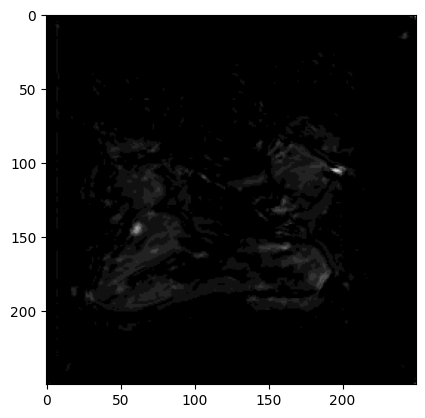

53 30


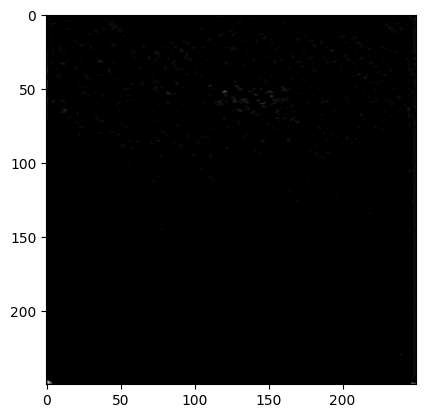

51 30


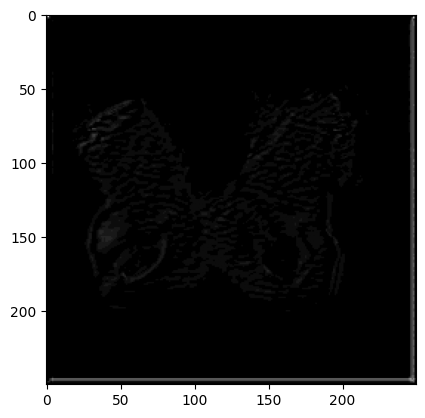

46 30


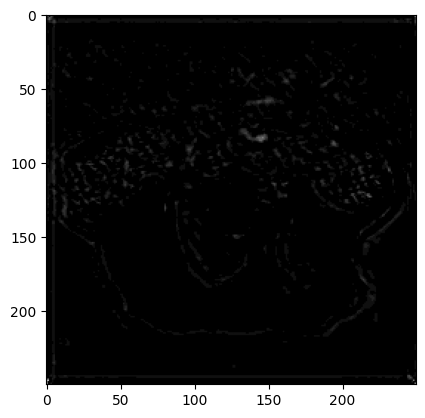

215 30


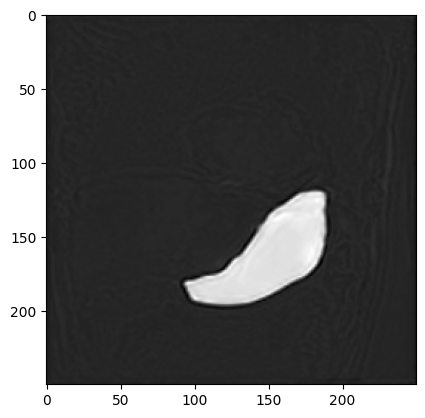

215 32


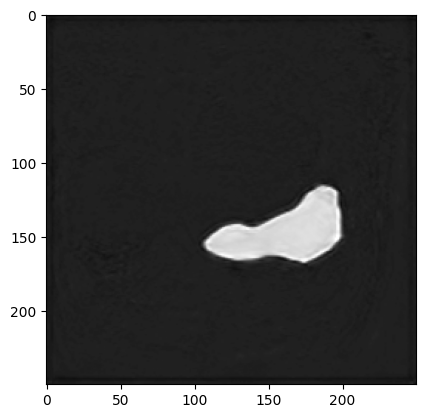

215 30


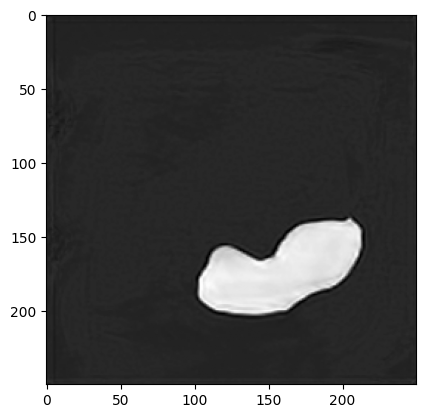

49 30


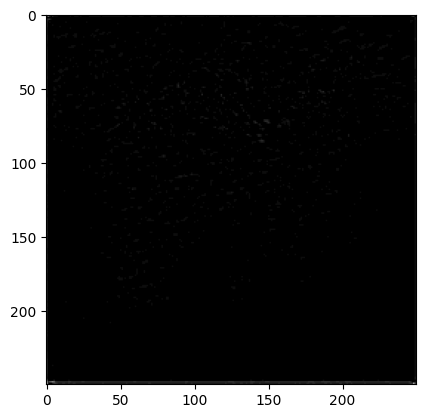

53 30


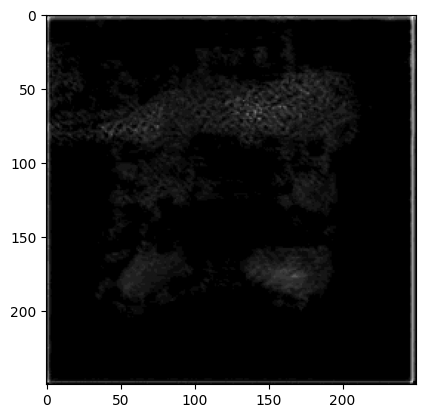

204 30


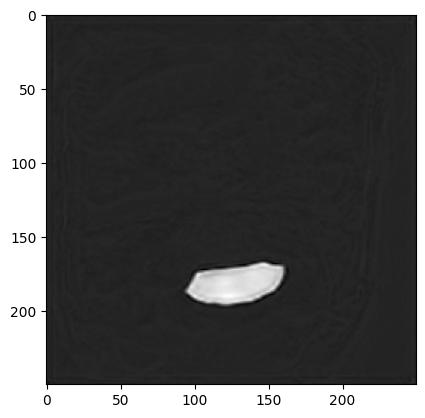

In [13]:
import matplotlib.pyplot as plt
for file in synthetic_mask_samples[:10]:
    mask_path = os.path.join(train_folder_path, file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    print(mask.flatten().max(), mask.flatten().min())
    plt.imshow(mask, cmap='gray')
    plt.show()